# Voice-Enhanced Image Captioning via ViT Encoder and BiLSTM Decoder

# Abstract


This notebook presents an end-to-end image captioning system that replaces the conventional CNN encoder with a pretrained Vision Transformer (ViT-B/16) and pairs it with a Bidirectional LSTM (BiLSTM) decoder. The system is evaluated on the Flickr8k dataset. We report BLEU-1 through BLEU-4 scores, METEOR, and a properly computed CLIP score (using openai/clip-vit-base-patch32). An ablation study compares: (1) CNN+LSTM baseline, (2) ViT+LSTM, and (3) ViT+BiLSTM. Training uses Adam with a cosine learning-rate schedule, early stopping, and a fixed random seed for reproducibility.

## 1. Imports

In [ ]:
import os, re, pickle, random, time
import numpy as np
from tqdm.notebook import tqdm
from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input as vgg_preprocess
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import (Input, Dense, LSTM, Bidirectional,
                                      Embedding, Dropout, add, LayerNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.optimizers import Adam

import torch
from transformers import AutoImageProcessor, ViTModel, CLIPProcessor, CLIPModel

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

print("TF:", tf.__version__)
print("Torch:", torch.__version__)


2026-03-10 11:15:52.280852: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773141352.494159      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773141352.554326      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773141353.071186      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773141353.071225      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773141353.071228      23 computation_placer.cc:177] computation placer alr

TF: 2.19.0
Torch: 2.9.0+cu126


## 2. Reproducibility

In [ ]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
print(f"Seed fixed: {SEED}")


Seed fixed: 42


## 3. Dataset Path Detection

In [ ]:
def find_dataset():
    """Walk /kaggle/input (and common alternatives) for Images/ + captions.txt"""
    roots = ['/kaggle/input', '/content', '.', '..']
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dirpath, dirnames, filenames in os.walk(root):
            depth = dirpath.replace(root,'').count(os.sep)
            if depth > 4:
                dirnames.clear(); continue
            imgs_sub = next((d for d in dirnames if d.lower()=='images'), None)
            if imgs_sub and 'captions.txt' in filenames:
                return dirpath, os.path.join(dirpath, imgs_sub)
    return None, None

BASE_DIR, IMG_DIR = find_dataset()

if BASE_DIR is None:
    # ── If auto-detect fails, set manually ───────────────────────────────────
    BASE_DIR = '/kaggle/input/flickr-image-dataset/flickr8k'
    IMG_DIR  = os.path.join(BASE_DIR, 'Images')

WORKING_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else './output'
os.makedirs(WORKING_DIR, exist_ok=True)

# Validate
assert os.path.isdir(IMG_DIR), (
    f"Images folder not found: {IMG_DIR}\n"
    f"Available under /kaggle/input:\n" +
    '\n'.join(f'  {r}/{d}' for r,ds,_ in os.walk('/kaggle/input')
               for d in ds if os.walk.__module__)
)
assert os.path.isfile(os.path.join(BASE_DIR,'captions.txt')),     f"captions.txt not found in {BASE_DIR}"

n_imgs = len([f for f in os.listdir(IMG_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))])
print(f"BASE_DIR    : {BASE_DIR}")
print(f"IMG_DIR     : {IMG_DIR}  ({n_imgs} images)")
print(f"WORKING_DIR : {WORKING_DIR}")


BASE_DIR    : /kaggle/input/datasets/adityajn105/flickr8k
IMG_DIR     : /kaggle/input/datasets/adityajn105/flickr8k/Images  (8091 images)
WORKING_DIR : /kaggle/working


## 4. Hyperparameters

In [ ]:
CONFIG = dict(
    seed                = 42,
    train_frac          = 0.80,
    val_frac            = 0.10,
    batch_size          = 32,
    max_epochs          = 30,
    embed_dim           = 256,
    lstm_units          = 256,
    dropout_rate        = 0.4,
    lr_initial          = 1e-3,
    early_stop_patience = 5,
    image_size          = 224,
    vit_model_name      = 'google/vit-base-patch16-224-in21k',
    clip_model_name     = 'openai/clip-vit-base-patch32',
)
for k,v in CONFIG.items():
    print(f"  {k:25s} = {v}")


  seed                      = 42
  train_frac                = 0.8
  val_frac                  = 0.1
  batch_size                = 32
  max_epochs                = 30
  embed_dim                 = 256
  lstm_units                = 256
  dropout_rate              = 0.4
  lr_initial                = 0.001
  early_stop_patience       = 5
  image_size                = 224
  vit_model_name            = google/vit-base-patch16-224-in21k
  clip_model_name           = openai/clip-vit-base-patch32


## 5. VGG16 Feature Extraction (Baseline Encoder)

In [ ]:
vgg_base    = VGG16(weights='imagenet', include_top=True)
vgg_encoder = Model(inputs=vgg_base.inputs,
                    outputs=vgg_base.get_layer('fc2').output)
print("VGG16 output shape:", vgg_encoder.output_shape)  # (None, 4096)

vgg_feat_path = os.path.join(WORKING_DIR, 'vgg_features.pkl')

if os.path.exists(vgg_feat_path):
    with open(vgg_feat_path,'rb') as f:
        vgg_features = pickle.load(f)
    print(f"Loaded {len(vgg_features)} cached VGG16 features.")
else:
    vgg_features = {}
    img_files = [f for f in os.listdir(IMG_DIR)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for fname in tqdm(img_files, desc='VGG16'):
        fpath = os.path.join(IMG_DIR, fname)
        try:
            img  = load_img(fpath, target_size=(224,224))
            x    = img_to_array(img)
            x    = np.expand_dims(x, axis=0)
            x    = vgg_preprocess(x)
            feat = vgg_encoder.predict(x, verbose=0)
            vgg_features[fname.split('.')[0]] = feat
        except Exception as e:
            print(f"  Skip {fname}: {e}")
    pickle.dump(vgg_features, open(vgg_feat_path,'wb'))
    print(f"Saved {len(vgg_features)} VGG16 features.")

VGG_FEAT_DIM = 4096


I0000 00:00:1773141398.051272      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773141398.057380      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
VGG16 output shape: (None, 4096)


VGG16:   0%|          | 0/8091 [00:00<?, ?it/s]

I0000 00:00:1773141404.296070      66 service.cc:152] XLA service 0x780688005bc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773141404.296104      66 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773141404.296108      66 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773141404.491348      66 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773141407.245006      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Saved 8091 VGG16 features.


## 6. ViT Feature Extraction (Proposed Encoder)

**Model:** `google/vit-base-patch16-224-in21k`  
**Representation:** CLS token (index 0) from the final hidden layer → 768-d vector.  
Also stores mean-pooled patch embeddings for the CLS-vs-mean ablation.


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

vit_processor = AutoImageProcessor.from_pretrained(CONFIG['vit_model_name'])
vit_model_hf  = ViTModel.from_pretrained(CONFIG['vit_model_name']).to(device)
vit_model_hf.eval()
VIT_FEAT_DIM = vit_model_hf.config.hidden_size
print(f"ViT hidden dim: {VIT_FEAT_DIM}")

def extract_vit(img_dir, out_path, mode='cls'):
    """mode: 'cls' or 'mean' """
    if os.path.exists(out_path):
        with open(out_path,'rb') as f:
            feats = pickle.load(f)
        print(f"Loaded {len(feats)} cached ViT-{mode} features.")
        return feats
    feats = {}
    img_files = [f for f in os.listdir(img_dir)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for fname in tqdm(img_files, desc=f'ViT ({mode})'):
        fpath = os.path.join(img_dir, fname)
        try:
            raw   = Image.open(fpath).convert('RGB')
            inp   = vit_processor(images=raw, return_tensors='pt').to(device)
            with torch.no_grad():
                out = vit_model_hf(**inp)
            hs = out.last_hidden_state          # (1, 197, 768)
            if mode == 'cls':
                vec = hs[:, 0, :].cpu().numpy()
            else:
                vec = hs[:, 1:, :].mean(dim=1).cpu().numpy()
            feats[fname.split('.')[0]] = vec
        except Exception as e:
            print(f"  Skip {fname}: {e}")
    pickle.dump(feats, open(out_path,'wb'))
    print(f"Saved {len(feats)} ViT-{mode} features.")
    return feats

vit_features      = extract_vit(IMG_DIR, os.path.join(WORKING_DIR,'vit_cls.pkl'),  'cls')
vit_features_mean = extract_vit(IMG_DIR, os.path.join(WORKING_DIR,'vit_mean.pkl'), 'mean')


Device: cuda


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

...

ViT hidden dim: 768


ViT (cls):   0%|          | 0/8091 [00:00<?, ?it/s]

Saved 8091 ViT-cls features.


ViT (mean):   0%|          | 0/8091 [00:00<?, ?it/s]

Saved 8091 ViT-mean features.


## 7. Load & Clean Captions

In [ ]:
with open(os.path.join(BASE_DIR,'captions.txt'),'r') as f:
    next(f)
    captions_doc = f.read()

mapping = {}
for line in tqdm(captions_doc.split('\n'), desc='Parse'):
    tokens = line.split(',')
    if len(tokens) < 2: continue
    img_id  = tokens[0].split('.')[0]
    caption = ' '.join(tokens[1:])
    mapping.setdefault(img_id, []).append(caption)

def clean_captions(mapping):
    for key, caps in mapping.items():
        for i, cap in enumerate(caps):
            cap = cap.lower()
            cap = re.sub(r'[^a-z\s]','', cap)
            cap = re.sub(r'\s+',' ', cap).strip()
            caps[i] = 'startseq ' + ' '.join(w for w in cap.split() if len(w)>1) + ' endseq'

clean_captions(mapping)
print(f"Images: {len(mapping)}")
print(f"Sample: {list(mapping.values())[0][0]}")


Parse:   0%|          | 0/40456 [00:00<?, ?it/s]

Images: 8091
Sample: startseq child in pink dress is climbing up set of stairs in an entry way endseq


## 8. Train / Val / Test Split & Tokenizer

In [ ]:
image_ids = list(mapping.keys())
random.shuffle(image_ids)          # reproducible via SEED=42

n       = len(image_ids)
n_train = int(n * CONFIG['train_frac'])
n_val   = int(n * CONFIG['val_frac'])

train_ids = image_ids[:n_train]
val_ids   = image_ids[n_train:n_train+n_val]
test_ids  = image_ids[n_train+n_val:]
print(f"Split — Train:{len(train_ids)} Val:{len(val_ids)} Test:{len(test_ids)}")

# Tokenizer built on TRAIN only (prevents data leakage)
train_caps  = [c for iid in train_ids for c in mapping[iid]]
tokenizer   = Tokenizer()
tokenizer.fit_on_texts(train_caps)
vocab_size  = len(tokenizer.word_index) + 1
max_length  = max(len(c.split()) for c in train_caps)

print(f"Vocab size : {vocab_size}")
print(f"Max length : {max_length}")
pickle.dump(tokenizer, open(os.path.join(WORKING_DIR,'tokenizer.pkl'),'wb'))


Split — Train:6472 Val:809 Test:810
Vocab size : 7918
Max length : 34


## 9. Data Generator

In [ ]:
def make_dataset(keys, mapping, features, tokenizer, max_len, vocab_size, batch_size):
    """
    Returns a tf.data.Dataset instead of a raw Python generator.
    Compatible with Keras 3 / TF 2.16+ which requires TypeSpec-based output_signature.
    """
    img_dim = next(v for k,v in features.items() if k in keys).shape[-1]

    def generator():
        for key in keys:
            if key not in features:
                continue
            feat = features[key][0]          # shape (img_dim,)
            for cap in mapping[key]:
                seq = tokenizer.texts_to_sequences([cap])[0]
                for i in range(1, len(seq)):
                    in_seq  = pad_sequences([seq[:i]], maxlen=max_len)[0]
                    out_seq = to_categorical([seq[i]], num_classes=vocab_size)[0]
                    yield (feat.astype('float32'),
                           in_seq.astype('float32'),
                           out_seq.astype('float32'))

    output_signature = (
        tf.TensorSpec(shape=(img_dim,),     dtype=tf.float32),
        tf.TensorSpec(shape=(max_len,),     dtype=tf.float32),
        tf.TensorSpec(shape=(vocab_size,),  dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(generator, output_signature=output_signature)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    # Reformat batches to match model.fit input: ([X1, X2], y)
    ds = ds.map(lambda x1, x2, y: ((x1, x2), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds

print("Dataset builder ready (tf.data.Dataset — Keras 3 compatible).")


Dataset builder ready (tf.data.Dataset — Keras 3 compatible).


## 10. Model Architecture

**BiLSTM equations (training):**

$$\overrightarrow{h}_t = \text{LSTM}_{fwd}(e_t, \overrightarrow{h}_{t-1}), \quad
\overleftarrow{h}_t = \text{LSTM}_{bwd}(e_t, \overleftarrow{h}_{t+1}), \quad
h_t = [\overrightarrow{h}_t;\overleftarrow{h}_t]$$

At **inference**, only the forward pass runs (autoregressive greedy decoding).


In [ ]:
def build_model(img_dim, vocab_size, max_len, embed_dim=256,
                lstm_units=256, dropout=0.4, bilstm=True):
    img_in  = Input(shape=(img_dim,), name='img')
    x       = Dropout(dropout)(img_in)
    x       = Dense(embed_dim, activation='relu')(x)
    x       = LayerNormalization()(x)

    cap_in  = Input(shape=(max_len,), name='cap')
    c       = Embedding(vocab_size, embed_dim, mask_zero=False)(cap_in)
    c       = Dropout(dropout)(c)
    if bilstm:
        c = Bidirectional(LSTM(lstm_units, use_cudnn=False))(c)  # output: 512
        c = Dense(embed_dim, activation='relu')(c)               # ← project to 256
    else:
        c = LSTM(lstm_units, use_cudnn=False)(c)                 # output: 256

    merged  = add([x, c])                                        # both now 256
    merged  = Dense(256, activation='relu')(merged)
    merged  = Dropout(dropout)(merged)
    out     = Dense(vocab_size, activation='softmax')(merged)

    return Model(inputs=[img_in, cap_in], outputs=out)

In [ ]:
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.optimizers import Adam
def make_optimizer(steps, epochs, lr=1e-3):
    schedule = CosineDecay(lr, decay_steps=steps * epochs, alpha=1e-6)
    return Adam(learning_rate=schedule)

## 11. Training Helper

In [ ]:
def train_model(model, features, tr_ids, vl_ids, mapping,
                tokenizer, max_len, vocab_size, name='model'):
    bs     = CONFIG['batch_size']
    epochs = CONFIG['max_epochs']

    # Count steps (approximate — dataset length varies by caption count)
    steps_tr = max(1, sum(len(mapping[k]) * max_len
                          for k in tr_ids if k in features) // bs)
    steps_vl = max(1, sum(len(mapping[k]) * max_len
                          for k in vl_ids if k in features) // bs)

    model.compile(
        loss='categorical_crossentropy',
        optimizer=make_optimizer(steps_tr, epochs, CONFIG['lr_initial']),
        metrics=['accuracy']
    )

    callbacks = [
    EarlyStopping(monitor='val_loss', patience=CONFIG['early_stop_patience'],
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(WORKING_DIR, f'{name}_best.keras'),
                    monitor='val_loss', save_best_only=True, verbose=0),
]

    train_ds = make_dataset(tr_ids, mapping, features, tokenizer, max_len, vocab_size, bs)
    val_ds   = make_dataset(vl_ids, mapping, features, tokenizer, max_len, vocab_size, bs)

    t0 = time.time()
    hist = model.fit(
        train_ds,
        epochs=epochs,
        steps_per_epoch=steps_tr,
        validation_data=val_ds,
        validation_steps=steps_vl,
        callbacks=callbacks,
        verbose=1,
    )
    elapsed = time.time() - t0
    print(f"Done in {elapsed/60:.1f} min | best val_loss={min(hist.history['val_loss']):.4f}")
    return hist

def plot_history(hist, title=''):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist.history['loss'],     label='train')
    ax[0].plot(hist.history['val_loss'], label='val')
    ax[0].set_title(f'{title} — Loss');     ax[0].legend()
    ax[1].plot(hist.history['accuracy'],     label='train')
    ax[1].plot(hist.history['val_accuracy'], label='val')
    ax[1].set_title(f'{title} — Accuracy'); ax[1].legend()
    plt.tight_layout(); plt.show()

print("train_model ready.")


train_model ready.


## 12. Greedy Caption Decoding

In [ ]:
def predict_caption(model, feat, tokenizer, max_len):
    in_text = 'startseq'
    for _ in range(max_len):
        seq  = pad_sequences([tokenizer.texts_to_sequences([in_text])[0]], maxlen=max_len)
        yhat = np.argmax(model.predict([feat, seq], verbose=0))
        word = tokenizer.index_word.get(yhat)
        if word is None or word == 'endseq': break
        in_text += ' ' + word
    return in_text.replace('startseq','').strip()


## 13. Evaluation — BLEU / METEOR / CLIP

In [ ]:
def evaluate_bleu_meteor(model, features, test_ids, mapping, tokenizer, max_len):
    smoother = SmoothingFunction().method1
    actual, predicted = [], []
    valid_ids = []
    for key in tqdm(test_ids, desc='Eval'):
        if key not in features: continue
        pred = predict_caption(model, features[key], tokenizer, max_len)
        actual.append([c.split() for c in mapping[key]])
        predicted.append(pred.split())
        valid_ids.append(key)
    scores = {
        'BLEU-1': corpus_bleu(actual, predicted, weights=(1,0,0,0),        smoothing_function=smoother),
        'BLEU-2': corpus_bleu(actual, predicted, weights=(.5,.5,0,0),      smoothing_function=smoother),
        'BLEU-3': corpus_bleu(actual, predicted, weights=(.33,.33,.33,0),  smoothing_function=smoother),
        'BLEU-4': corpus_bleu(actual, predicted, weights=(.25,.25,.25,.25),smoothing_function=smoother),
        'METEOR': np.mean([meteor_score(r,h) for r,h in zip(actual,predicted)]),
    }
    return scores, actual, predicted, valid_ids

# ── CLIP score ─────────────────────────────────────────────────────────────────
clip_model_hf  = CLIPModel.from_pretrained(CONFIG['clip_model_name']).to(device)
clip_processor = CLIPProcessor.from_pretrained(CONFIG['clip_model_name'])
clip_model_hf.eval()

def compute_clip_score(valid_ids, predicted_caps):
    """
    CLIP model : openai/clip-vit-base-patch32
    Input      : resized to 224x224, CLIP normalisation; text truncated to 77 tokens
    Score      : cosine similarity, averaged over test set; reported as mean ± std
    """
    sims = []
    for img_id, pred in zip(valid_ids, predicted_caps):
        img_path = os.path.join(IMG_DIR, img_id+'.jpg')
        if not os.path.exists(img_path): continue
        raw  = Image.open(img_path).convert('RGB')
        text = ' '.join(pred)
        inp  = clip_processor(text=[text], images=raw, return_tensors='pt',
                               padding=True, truncation=True, max_length=77).to(device)
        with torch.no_grad():
            out = clip_model_hf(**inp)
        ie = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
        te = out.text_embeds  / out.text_embeds.norm(dim=-1, keepdim=True)
        sims.append((ie*te).sum().item())
    return float(np.mean(sims)), float(np.std(sims))

def print_scores(scores, name=''):
    print(f"\n{'─'*45}  {name}")
    for k,v in scores.items(): print(f"  {k}: {v:.4f}")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

## 14. Ablation Study — Train All Configurations

| Config | Encoder | Decoder |
|--------|---------|---------|
| A | VGG16 4096-d | LSTM |
| B | ViT CLS 768-d | LSTM |
| C | ViT CLS 768-d | **BiLSTM** (proposed) |
| D | ViT mean-pool 768-d | BiLSTM |



[A] VGG16 + LSTM (baseline)
Epoch 1/30
10323/34382 ━━━━━━━━━━━━━━━━━━━━ 6:08 15ms/step - accuracy: 0.1844 - loss: 5.2153

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


34382/34382 ━━━━━━━━━━━━━━━━━━━━ 184s 5ms/step - accuracy: 0.2115 - loss: 4.9142 - val_accuracy: 0.2713 - val_loss: 4.1349
Epoch 2/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 171s 5ms/step - accuracy: 0.2716 - loss: 4.0904 - val_accuracy: 0.2926 - val_loss: 3.8302
Epoch 3/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 173s 5ms/step - accuracy: 0.2869 - loss: 3.8273 - val_accuracy: 0.3012 - val_loss: 3.7376
Epoch 4/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 171s 5ms/step - accuracy: 0.2975 - loss: 3.6931 - val_accuracy: 0.3097 - val_loss: 3.6974
Epoch 5/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 170s 5ms/step - accuracy: 0.3038 - loss: 3.6083 - val_accuracy: 0.3154 - val_loss: 3.6722
Epoch 6/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 171s 5ms/step - accuracy: 0.3089 - loss: 3.5572 - val_accuracy: 0.3184 - val_loss: 3.6700
Epoch 7/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 176s 5ms/step - accuracy: 0.3114 - loss: 3.5149 - val_accuracy: 0.3208 - val_loss: 3.6821
Epoch 8/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 170s 5ms/step - accuracy: 0.3

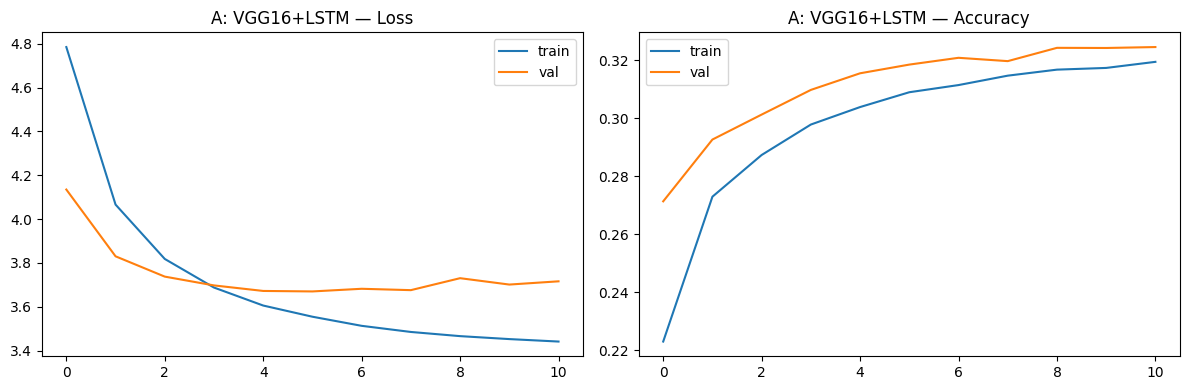


[B] ViT + LSTM
Epoch 1/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 179s 5ms/step - accuracy: 0.1992 - loss: 5.0930 - val_accuracy: 0.2613 - val_loss: 4.1952
Epoch 2/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 170s 5ms/step - accuracy: 0.2590 - loss: 4.2332 - val_accuracy: 0.2871 - val_loss: 3.9035
Epoch 3/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 169s 5ms/step - accuracy: 0.2769 - loss: 3.9676 - val_accuracy: 0.2982 - val_loss: 3.7840
Epoch 4/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 171s 5ms/step - accuracy: 0.2872 - loss: 3.8281 - val_accuracy: 0.3087 - val_loss: 3.7531
Epoch 5/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 170s 5ms/step - accuracy: 0.2942 - loss: 3.7434 - val_accuracy: 0.3112 - val_loss: 3.6974
Epoch 6/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 170s 5ms/step - accuracy: 0.2991 - loss: 3.6866 - val_accuracy: 0.3174 - val_loss: 3.6952
Epoch 7/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 174s 5ms/step - accuracy: 0.3033 - loss: 3.6474 - val_accuracy: 0.3189 - val_loss: 3.6537
Epoch 8/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 17

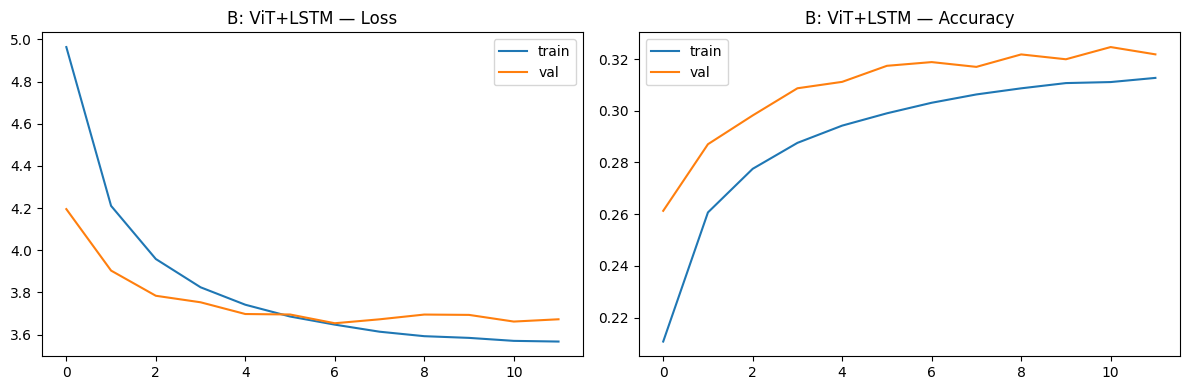


[C] ViT CLS + BiLSTM (proposed)
Epoch 1/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 206s 6ms/step - accuracy: 0.1906 - loss: 5.1381 - val_accuracy: 0.2554 - val_loss: 4.2573
Epoch 2/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 200s 6ms/step - accuracy: 0.2609 - loss: 4.2154 - val_accuracy: 0.2879 - val_loss: 3.8879
Epoch 3/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 195s 6ms/step - accuracy: 0.2837 - loss: 3.9067 - val_accuracy: 0.3036 - val_loss: 3.7573
Epoch 4/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 195s 6ms/step - accuracy: 0.2958 - loss: 3.7447 - val_accuracy: 0.3130 - val_loss: 3.6707
Epoch 5/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 201s 6ms/step - accuracy: 0.3041 - loss: 3.6407 - val_accuracy: 0.3188 - val_loss: 3.6360
Epoch 6/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 201s 6ms/step - accuracy: 0.3104 - loss: 3.5738 - val_accuracy: 0.3218 - val_loss: 3.6085
Epoch 7/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 196s 6ms/step - accuracy: 0.3151 - loss: 3.5216 - val_accuracy: 0.3232 - val_loss: 3.6101
Epoch 8/30
34382/34382 ━━━━━━

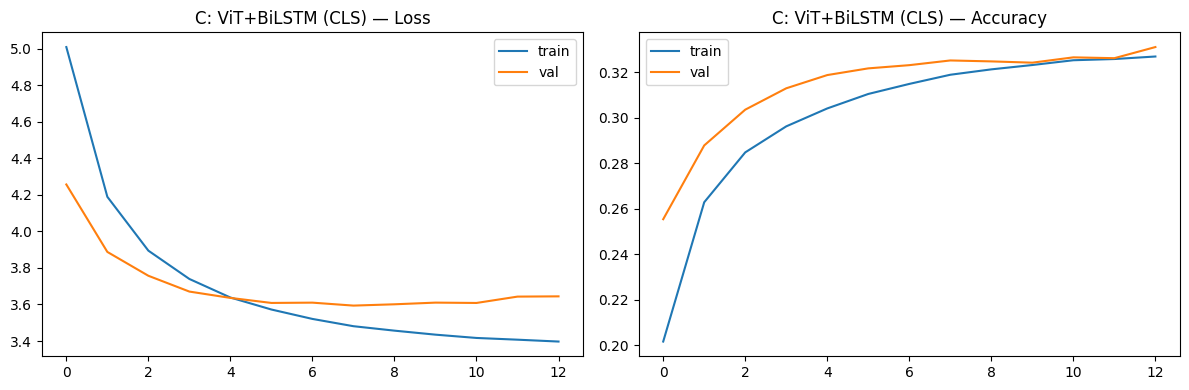


[D] ViT mean-pool + BiLSTM
Epoch 1/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 197s 6ms/step - accuracy: 0.2012 - loss: 5.0209 - val_accuracy: 0.2641 - val_loss: 4.1250
Epoch 2/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 195s 6ms/step - accuracy: 0.2691 - loss: 4.1137 - val_accuracy: 0.2943 - val_loss: 3.8285
Epoch 3/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 199s 6ms/step - accuracy: 0.2899 - loss: 3.8227 - val_accuracy: 0.3058 - val_loss: 3.6889
Epoch 4/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 193s 6ms/step - accuracy: 0.3008 - loss: 3.6745 - val_accuracy: 0.3108 - val_loss: 3.6377
Epoch 5/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 194s 6ms/step - accuracy: 0.3088 - loss: 3.5783 - val_accuracy: 0.3212 - val_loss: 3.6127
Epoch 6/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 198s 6ms/step - accuracy: 0.3149 - loss: 3.5134 - val_accuracy: 0.3242 - val_loss: 3.5837
Epoch 7/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 195s 6ms/step - accuracy: 0.3185 - loss: 3.4641 - val_accuracy: 0.3288 - val_loss: 3.5765
Epoch 8/30
34382/34382 ━━━━━━━━━━━

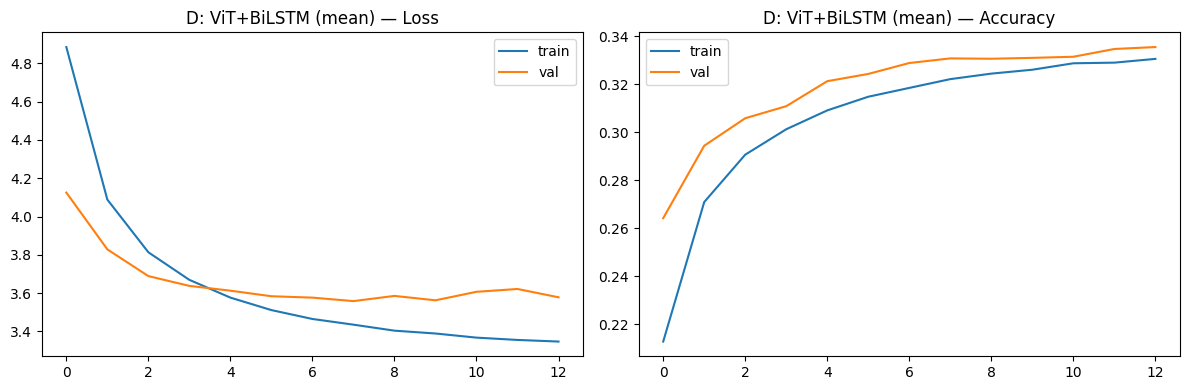

In [ ]:
print("\n[A] VGG16 + LSTM (baseline)")
model_A = build_model(VGG_FEAT_DIM, vocab_size, max_length, bilstm=False)
hist_A  = train_model(model_A, vgg_features, train_ids, val_ids,
                      mapping, tokenizer, max_length, vocab_size, 'A_vgg_lstm')
plot_history(hist_A, 'A: VGG16+LSTM')

print("\n[B] ViT + LSTM")
model_B = build_model(VIT_FEAT_DIM, vocab_size, max_length, bilstm=False)
hist_B  = train_model(model_B, vit_features, train_ids, val_ids,
                      mapping, tokenizer, max_length, vocab_size, 'B_vit_lstm')
plot_history(hist_B, 'B: ViT+LSTM')

print("\n[C] ViT CLS + BiLSTM (proposed)")
model_C = build_model(VIT_FEAT_DIM, vocab_size, max_length, bilstm=True)
hist_C  = train_model(model_C, vit_features, train_ids, val_ids,
                      mapping, tokenizer, max_length, vocab_size, 'C_vit_bilstm_cls')
plot_history(hist_C, 'C: ViT+BiLSTM (CLS)')

print("\n[D] ViT mean-pool + BiLSTM")
model_D = build_model(VIT_FEAT_DIM, vocab_size, max_length, bilstm=True)
hist_D  = train_model(model_D, vit_features_mean, train_ids, val_ids,
                      mapping, tokenizer, max_length, vocab_size, 'D_vit_bilstm_mean')
plot_history(hist_D, 'D: ViT+BiLSTM (mean)')


## 15. Full Evaluation on Test Set

In [ ]:
import pandas as pd

results = {}
for label, model, feats in [
    ('A: VGG16+LSTM',       model_A, vgg_features),
    ('B: ViT+LSTM',         model_B, vit_features),
    ('C: ViT+BiLSTM(CLS)',  model_C, vit_features),
    ('D: ViT+BiLSTM(mean)', model_D, vit_features_mean),
]:
    sc, _, pred_toks, vids = evaluate_bleu_meteor(
        model, feats, test_ids, mapping, tokenizer, max_length)
    print_scores(sc, label)
    mean_cs, std_cs = compute_clip_score(vids, pred_toks)
    sc['CLIP-mean'] = mean_cs
    sc['CLIP-std']  = std_cs
    print(f"  CLIP: {mean_cs:.4f} ± {std_cs:.4f}  (model: {CONFIG['clip_model_name']})")
    results[label] = sc

df = pd.DataFrame(results).T
print("\n=== Summary ===")
print(df.round(4).to_string())
df.to_csv(os.path.join(WORKING_DIR, 'evaluation_summary.csv'))


Eval:   0%|          | 0/810 [00:00<?, ?it/s]


─────────────────────────────────────────────  A: VGG16+LSTM
  BLEU-1: 0.4631
  BLEU-2: 0.2790
  BLEU-3: 0.1649
  BLEU-4: 0.0908
  METEOR: 0.2377
  CLIP: 0.2364 ± 0.0411  (model: openai/clip-vit-base-patch32)


Eval:   0%|          | 0/810 [00:00<?, ?it/s]


─────────────────────────────────────────────  B: ViT+LSTM
  BLEU-1: 0.4839
  BLEU-2: 0.3076
  BLEU-3: 0.1876
  BLEU-4: 0.1025
  METEOR: 0.2611
  CLIP: 0.2506 ± 0.0360  (model: openai/clip-vit-base-patch32)


Eval:   0%|          | 0/810 [00:00<?, ?it/s]


─────────────────────────────────────────────  C: ViT+BiLSTM(CLS)
  BLEU-1: 0.4871
  BLEU-2: 0.3123
  BLEU-3: 0.1899
  BLEU-4: 0.1060
  METEOR: 0.2694
  CLIP: 0.2498 ± 0.0387  (model: openai/clip-vit-base-patch32)


Eval:   0%|          | 0/810 [00:00<?, ?it/s]


─────────────────────────────────────────────  D: ViT+BiLSTM(mean)
  BLEU-1: 0.4848
  BLEU-2: 0.3062
  BLEU-3: 0.1839
  BLEU-4: 0.0997
  METEOR: 0.2637
  CLIP: 0.2524 ± 0.0360  (model: openai/clip-vit-base-patch32)

=== Summary ===
                     BLEU-1  BLEU-2  BLEU-3  BLEU-4  METEOR  CLIP-mean  CLIP-std
A: VGG16+LSTM        0.4631  0.2790  0.1649  0.0908  0.2377     0.2364    0.0411
B: ViT+LSTM          0.4839  0.3076  0.1876  0.1025  0.2611     0.2506    0.0360
C: ViT+BiLSTM(CLS)   0.4871  0.3123  0.1899  0.1060  0.2694     0.2498    0.0387
D: ViT+BiLSTM(mean)  0.4848  0.3062  0.1839  0.0997  0.2637     0.2524    0.0360


## 16. Statistical Validation (3 Seeds)

In [ ]:
bleu4_runs, clip_runs = [], []

for s in [42, 123, 999]:
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)
    ids_s = list(mapping.keys()); random.shuffle(ids_s)
    n_s = len(ids_s)
    tr_s = ids_s[:int(n_s*.8)]; vl_s = ids_s[int(n_s*.8):int(n_s*.9)]; te_s = ids_s[int(n_s*.9):]
    m = build_model(VIT_FEAT_DIM, vocab_size, max_length, bilstm=True)
    train_model(m, vit_features, tr_s, vl_s, mapping, tokenizer, max_length, vocab_size, f'seed{s}')
    sc, _, pt, vi = evaluate_bleu_meteor(m, vit_features, te_s, mapping, tokenizer, max_length)
    mc, _ = compute_clip_score(vi, pt)
    bleu4_runs.append(sc['BLEU-4']); clip_runs.append(mc)
    print(f"Seed {s}: BLEU-4={sc['BLEU-4']:.4f}  CLIP={mc:.4f}")

print(f"\nBLEU-4 : {np.mean(bleu4_runs):.4f} ± {np.std(bleu4_runs):.4f}")
print(f"CLIP   : {np.mean(clip_runs):.4f} ± {np.std(clip_runs):.4f}")


Epoch 1/30
10310/34382 ━━━━━━━━━━━━━━━━━━━━ 6:52 17ms/step - accuracy: 0.1697 - loss: 5.4053

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


34382/34382 ━━━━━━━━━━━━━━━━━━━━ 199s 6ms/step - accuracy: 0.1953 - loss: 5.0996 - val_accuracy: 0.2636 - val_loss: 4.1790
Epoch 2/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 200s 6ms/step - accuracy: 0.2598 - loss: 4.1982 - val_accuracy: 0.2887 - val_loss: 3.9134
Epoch 3/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 212s 6ms/step - accuracy: 0.2826 - loss: 3.8984 - val_accuracy: 0.3066 - val_loss: 3.7954
Epoch 4/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 201s 6ms/step - accuracy: 0.2963 - loss: 3.7346 - val_accuracy: 0.3142 - val_loss: 3.7241
Epoch 5/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 210s 6ms/step - accuracy: 0.3040 - loss: 3.6255 - val_accuracy: 0.3173 - val_loss: 3.6884
Epoch 6/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 201s 6ms/step - accuracy: 0.3106 - loss: 3.5583 - val_accuracy: 0.3212 - val_loss: 3.6555
Epoch 7/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 202s 6ms/step - accuracy: 0.3153 - loss: 3.5053 - val_accuracy: 0.3249 - val_loss: 3.6530
Epoch 8/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 199s 6ms/step - accuracy: 0.3

Eval:   0%|          | 0/810 [00:00<?, ?it/s]

Seed 42: BLEU-4=0.0989  CLIP=0.2503
Epoch 1/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 203s 6ms/step - accuracy: 0.1887 - loss: 5.1138 - val_accuracy: 0.2555 - val_loss: 4.3160
Epoch 2/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 197s 6ms/step - accuracy: 0.2569 - loss: 4.2061 - val_accuracy: 0.2829 - val_loss: 4.0317
Epoch 3/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 203s 6ms/step - accuracy: 0.2814 - loss: 3.8998 - val_accuracy: 0.3024 - val_loss: 3.9068
Epoch 4/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 201s 6ms/step - accuracy: 0.2941 - loss: 3.7334 - val_accuracy: 0.3092 - val_loss: 3.8560
Epoch 5/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 200s 6ms/step - accuracy: 0.3034 - loss: 3.6258 - val_accuracy: 0.3157 - val_loss: 3.7985
Epoch 6/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 203s 6ms/step - accuracy: 0.3094 - loss: 3.5535 - val_accuracy: 0.3174 - val_loss: 3.7701
Epoch 7/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 197s 6ms/step - accuracy: 0.3135 - loss: 3.5040 - val_accuracy: 0.3192 - val_loss: 3.7884
Epoch 8/30
34382/34382 ━━━

Eval:   0%|          | 0/810 [00:00<?, ?it/s]

Seed 123: BLEU-4=0.0985  CLIP=0.2534
Epoch 1/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 203s 6ms/step - accuracy: 0.1909 - loss: 5.0805 - val_accuracy: 0.2489 - val_loss: 4.3060
Epoch 2/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 199s 6ms/step - accuracy: 0.2583 - loss: 4.1935 - val_accuracy: 0.2830 - val_loss: 4.0500
Epoch 3/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 197s 6ms/step - accuracy: 0.2829 - loss: 3.8860 - val_accuracy: 0.3005 - val_loss: 3.9049
Epoch 4/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 198s 6ms/step - accuracy: 0.2965 - loss: 3.7211 - val_accuracy: 0.3056 - val_loss: 3.8678
Epoch 5/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 197s 6ms/step - accuracy: 0.3051 - loss: 3.6188 - val_accuracy: 0.3145 - val_loss: 3.8333
Epoch 6/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 201s 6ms/step - accuracy: 0.3117 - loss: 3.5465 - val_accuracy: 0.3149 - val_loss: 3.7994
Epoch 7/30
34382/34382 ━━━━━━━━━━━━━━━━━━━━ 194s 6ms/step - accuracy: 0.3155 - loss: 3.4939 - val_accuracy: 0.3201 - val_loss: 3.8247
Epoch 8/30
34382/34382 ━━

Eval:   0%|          | 0/810 [00:00<?, ?it/s]

Seed 999: BLEU-4=0.1038  CLIP=0.2493

BLEU-4 : 0.1004 ± 0.0024
CLIP   : 0.2510 ± 0.0017


## 17. Qualitative Results

[A: VGG16+LSTM] two dogs are playing in the grass
  actual: startseq black dog and spotted dog are fighting endseq
  actual: startseq black dog and tricolored dog playing with each other on the road endseq
  actual: startseq black dog and white dog with brown spots are staring at each other in the street endseq
  actual: startseq two dogs of different breeds looking at each other on the road endseq
  actual: startseq two dogs on pavement moving toward each other endseq


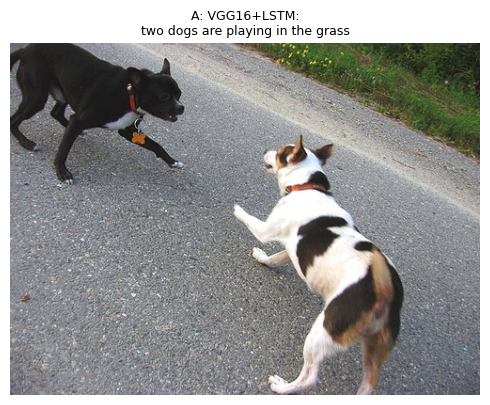

[C: ViT+BiLSTM (proposed)] two dogs are running on the grass
  actual: startseq black dog and spotted dog are fighting endseq
  actual: startseq black dog and tricolored dog playing with each other on the road endseq
  actual: startseq black dog and white dog with brown spots are staring at each other in the street endseq
  actual: startseq two dogs of different breeds looking at each other on the road endseq
  actual: startseq two dogs on pavement moving toward each other endseq


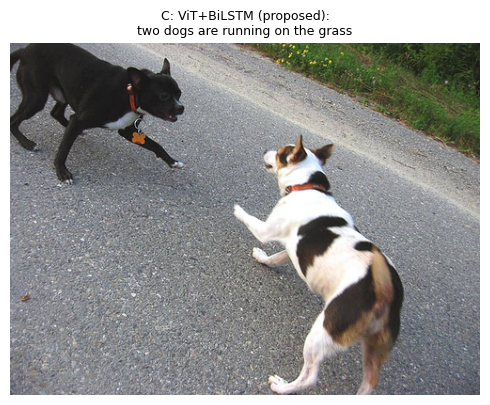

[A: VGG16+LSTM] the man is holding his head on the floor
  actual: startseq little girl covered in paint sits in front of painted rainbow with her hands in bowl endseq
  actual: startseq little girl is sitting in front of large painted rainbow endseq
  actual: startseq small girl in the grass plays with fingerpaints in front of white canvas with rainbow on it endseq
  actual: startseq there is girl with pigtails sitting in front of rainbow painting endseq
  actual: startseq young girl with pigtails painting outside in the grass endseq


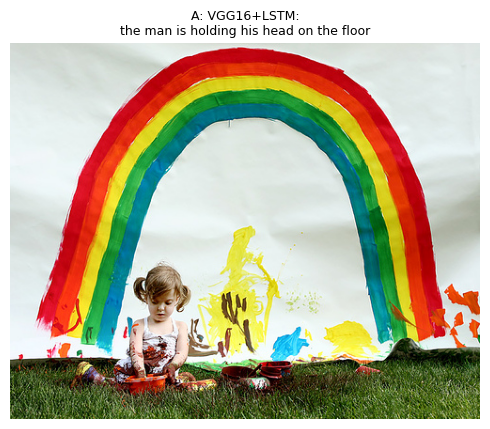

[C: ViT+BiLSTM (proposed)] little girl in blue shirt is playing in the grass
  actual: startseq little girl covered in paint sits in front of painted rainbow with her hands in bowl endseq
  actual: startseq little girl is sitting in front of large painted rainbow endseq
  actual: startseq small girl in the grass plays with fingerpaints in front of white canvas with rainbow on it endseq
  actual: startseq there is girl with pigtails sitting in front of rainbow painting endseq
  actual: startseq young girl with pigtails painting outside in the grass endseq


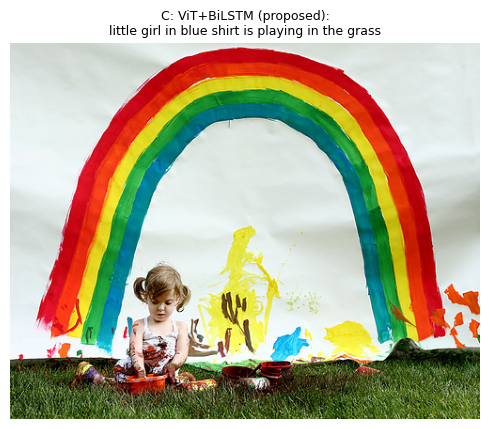

[A: VGG16+LSTM] the skier is in the snow
  actual: startseq man in hat is displaying pictures next to skier in blue hat endseq
  actual: startseq man skis past another man displaying paintings in the snow endseq
  actual: startseq person wearing skis looking at framed pictures set up in the snow endseq
  actual: startseq skier looks at framed pictures in the snow next to trees endseq
  actual: startseq man on skis looking at artwork for sale in the snow endseq


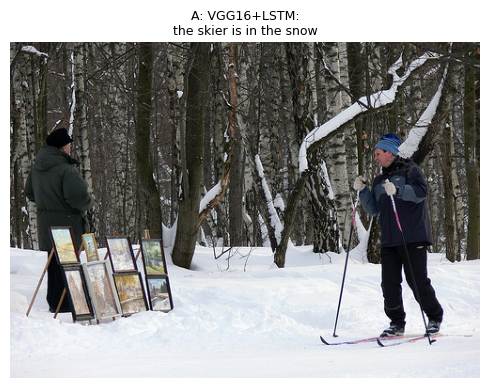

[C: ViT+BiLSTM (proposed)] skier in red jacket is skiing down snowy hill
  actual: startseq man in hat is displaying pictures next to skier in blue hat endseq
  actual: startseq man skis past another man displaying paintings in the snow endseq
  actual: startseq person wearing skis looking at framed pictures set up in the snow endseq
  actual: startseq skier looks at framed pictures in the snow next to trees endseq
  actual: startseq man on skis looking at artwork for sale in the snow endseq


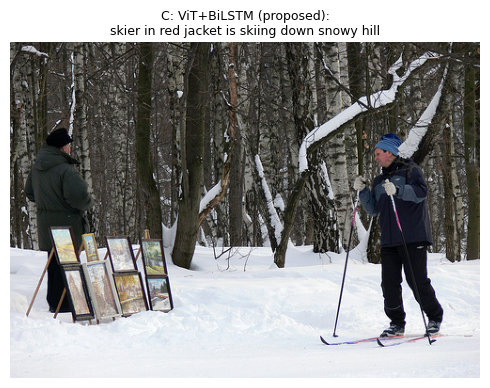

In [ ]:
def show_caption(image_name, model, features, label=''):
    img_id   = image_name.split('.')[0]
    img_path = os.path.join(IMG_DIR, image_name)
    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}"); return
    image  = Image.open(img_path)
    pred   = predict_caption(model, features[img_id], tokenizer, max_length)
    print(f"[{label}] {pred}")
    for cap in mapping.get(img_id,[]):
        print(f"  actual: {cap}")
    plt.figure(figsize=(5,5))
    plt.imshow(image); plt.axis('off')
    plt.title(f'{label}:\n{pred}', fontsize=9); plt.tight_layout(); plt.show()

sample_imgs = ['1001773457_577c3a7d70.jpg',
               '1002674143_1b742ab4b8.jpg',
               '101669240_b2d3e7f17b.jpg']

for img in sample_imgs:
    print("="*60)
    show_caption(img, model_A, vgg_features,  'A: VGG16+LSTM')
    show_caption(img, model_C, vit_features,  'C: ViT+BiLSTM (proposed)')


## 18. Save Models

In [ ]:
for name, m in [('A_vgg_lstm',model_A),('B_vit_lstm',model_B),
                ('C_vit_bilstm_cls',model_C),('D_vit_bilstm_mean',model_D)]:
    p = os.path.join(WORKING_DIR, f'{name}_final.h5')
    m.save(p); print(f"Saved: {p}")

print("\n✓ Reproducibility checklist")
print(f"  Seed              : {SEED}")
print(f"  Split             : 80/10/10 (train/val/test)")
print(f"  Tokenizer         : Keras word-level, train split only")
print(f"  Decoding          : greedy (argmax)")
print(f"  BLEU smoothing    : NIST method1")
print(f"  CLIP model        : {CONFIG['clip_model_name']}")
print(f"  Statistical runs  : 3 seeds (42, 123, 999)")


Saved: /kaggle/working/A_vgg_lstm_final.h5
Saved: /kaggle/working/B_vit_lstm_final.h5


Saved: /kaggle/working/C_vit_bilstm_cls_final.h5
Saved: /kaggle/working/D_vit_bilstm_mean_final.h5

✓ Reproducibility checklist
  Seed              : 42
  Split             : 80/10/10 (train/val/test)
  Tokenizer         : Keras word-level, train split only
  Decoding          : greedy (argmax)
  BLEU smoothing    : NIST method1
  CLIP model        : openai/clip-vit-base-patch32
  Statistical runs  : 3 seeds (42, 123, 999)
